# FAPE, COMPAS Stage 2: ThresholdOptimizer

Phase 4, Stage 2 fairness intervention in the criminal justice domain. The script applies Fairlearn's ThresholdOptimizer post-processing to the COMPAS baseline models under the demographic parity and equalized odds constraints, with race as the primary sensitive attribute and sex as the secondary one, and reports the change in fairness metrics alongside the accuracy cost. The positive class is recidivism, so a higher predicted rate is the adverse outcome. Race has six groups, and the test split holds 7 Asian defendants and 1 Native American defendant, so DPD and EOD over all six groups are set by those two groups (`group_size_check.py` reports the four-group values). The DIR in Figure 8 is Fairlearn's `demographic_parity_ratio`, lowest group rate over highest. ThresholdOptimizer.predict is seeded (random_state=42), so runs are repeatable.

Code: `src/stage2_compas_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_compas_threshold import run_stage2

run_stage2()

FAPE Phase 4, COMPAS Stage 2: ThresholdOptimizer
COMPAS loaded: 6,172 records, 6 racial groups, recidivism rate: 45.5%

Train: 4,937 | Test: 1,235
Recidivism rate, Train: 48.5% | Test: 48.4%

--- Baseline Results (Stage 1 reference) ---
  LogisticRegression     ACC=0.686 F1=0.650 DPD=0.545 EOD=0.701


  RandomForest           ACC=0.637 F1=0.622 DPD=0.568 EOD=0.686


  GradientBoosting       ACC=0.674 F1=0.647 DPD=0.857 EOD=1.000

--- ThresholdOptimizer, Demographic Parity Constraint ---
  LogisticRegression     ACC=0.657(-0.029) F1=0.659 DPD=0.714(+0.170) EOD=0.800


  RandomForest           ACC=0.602(-0.035) F1=0.590 DPD=0.714(+0.147) EOD=1.000


  GradientBoosting       ACC=0.675(+0.001) F1=0.640 DPD=0.571(-0.286) EOD=0.683

--- ThresholdOptimizer, Equalized Odds Constraint ---
  LogisticRegression     ACC=0.659(-0.027) F1=0.644 DPD=0.550 EOD=0.654(-0.047)


...

  GradientBoosting       ACC=0.666 DPD=0.013 EOD=0.098

--- Race-Level Prediction Rates, GB Before vs After EO Constraint ---


  African-American     n= 606 true=0.558 base=0.574 constrained=0.474
  Caucasian            n= 446 true=0.428 base=0.312 constrained=0.401
  Hispanic             n= 100 true=0.410 base=0.370 constrained=0.530
  Other                n=  75 true=0.347 base=0.213 constrained=0.360
  AA-Caucasian base gap: 0.263
  AA-Caucasian constrained gap: 0.072
  AA-Caucasian predicted-rate gap under GB: 0.263 -> 0.072 (EO constraint)

--- Key Findings ---
  Best DP constraint: GradientBoosting DPD=0.571
  Best EO constraint: LogisticRegression EOD=0.654
  GB DP constraint: DPD 0.857->0.571 (+33.3% improvement), accuracy change +0.001
  GB EO constraint: EOD 1.000->0.659 (+34.1% improvement), accuracy change +0.002
  Sex DPD after the DP constraint on sex, GB: 0.013
  DPD worse after the DP constraint (all six groups): LogisticRegression, RandomForest
Fig 1 saved, compas_accuracy_fairness_tradeoff.png


Fig 2 saved, compas_fairness_improvement.png
Fig 3 saved, compas_cost_gain_scatter.png
Fig 4 saved, compas_sex_fairness.png


Fig 5 saved, compas_f1_comparison.png
Fig 6 saved, compas_race_prediction_rates.png

--- FPR/FNR by Race, GB Before vs After EO Constraint ---
  African-American     FPR: 0.392→0.261 | FNR: 0.281→0.358
  Caucasian            FPR: 0.184→0.263 | FNR: 0.518→0.414
  Hispanic             FPR: 0.254→0.441 | FNR: 0.463→0.341
  Other                FPR: 0.102→0.204 | FNR: 0.577→0.346
  AA-Caucasian FPR gap: 0.207 -> -0.002
  AA-Caucasian FNR gap: -0.237 -> -0.056


Fig 7 saved, compas_fpr_fnr_by_race.png
Fig 8 saved, compas_dir_before_after.png

--- COMPAS Stage 2 complete ---
  8 figures saved to figures/stage2/


## 1. Accuracy and DPD, baseline and constrained

Accuracy and race demographic parity difference for each model at baseline and under each constraint.

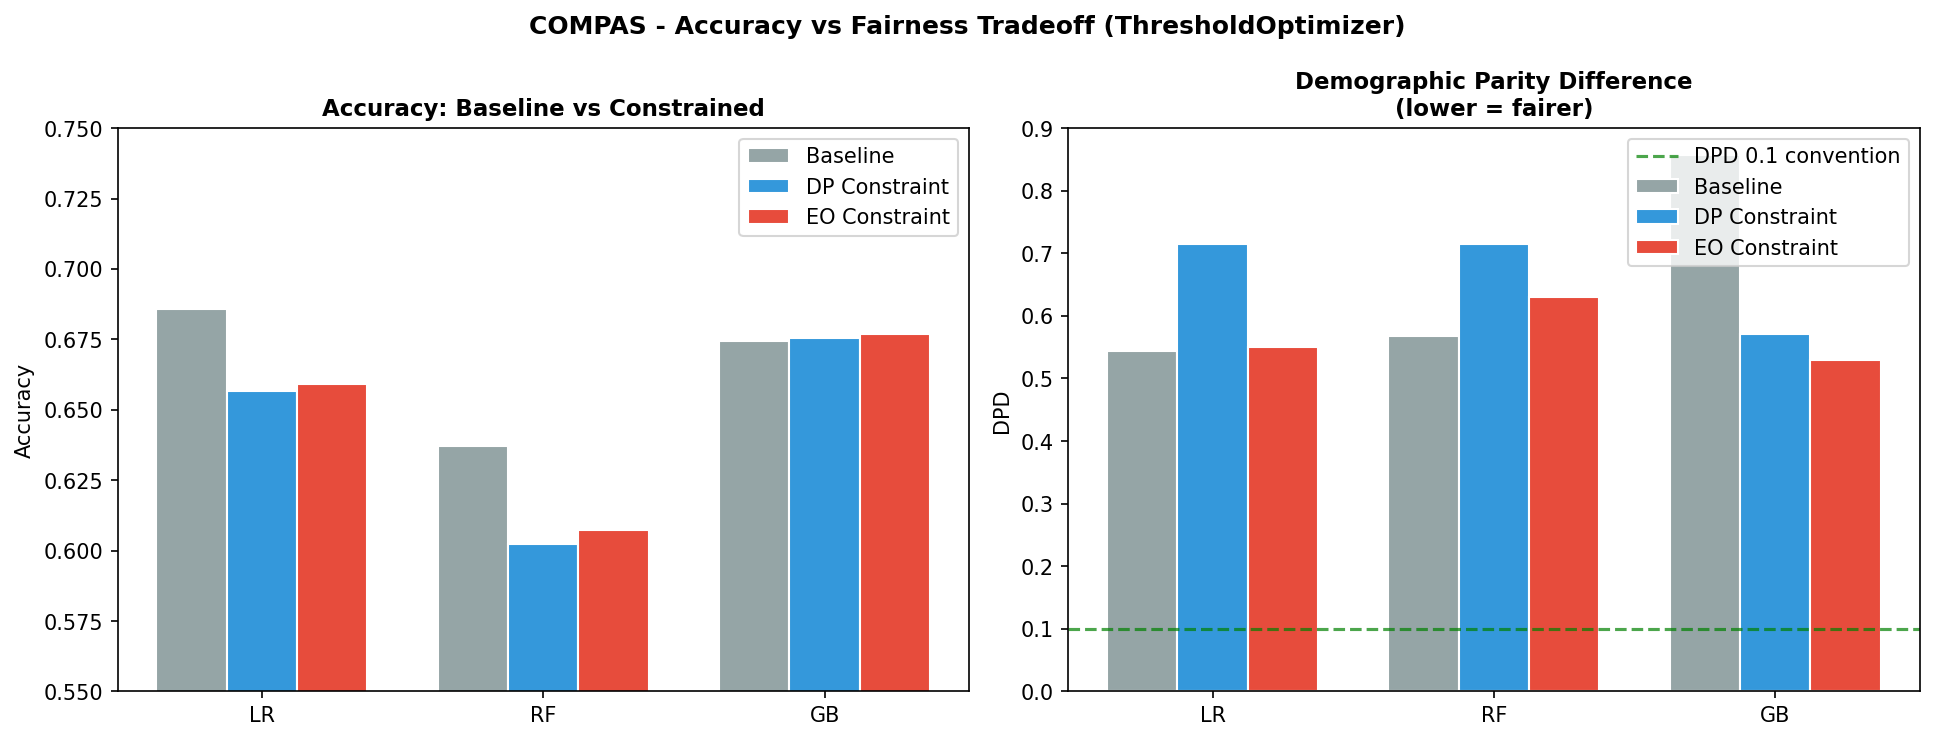

In [3]:
display(Image('figures/stage2/compas_accuracy_fairness_tradeoff.png'))

## 2. DPD and EOD by constraint

Race DPD before and after the demographic parity constraint, and race EOD before and after the equalized odds constraint.

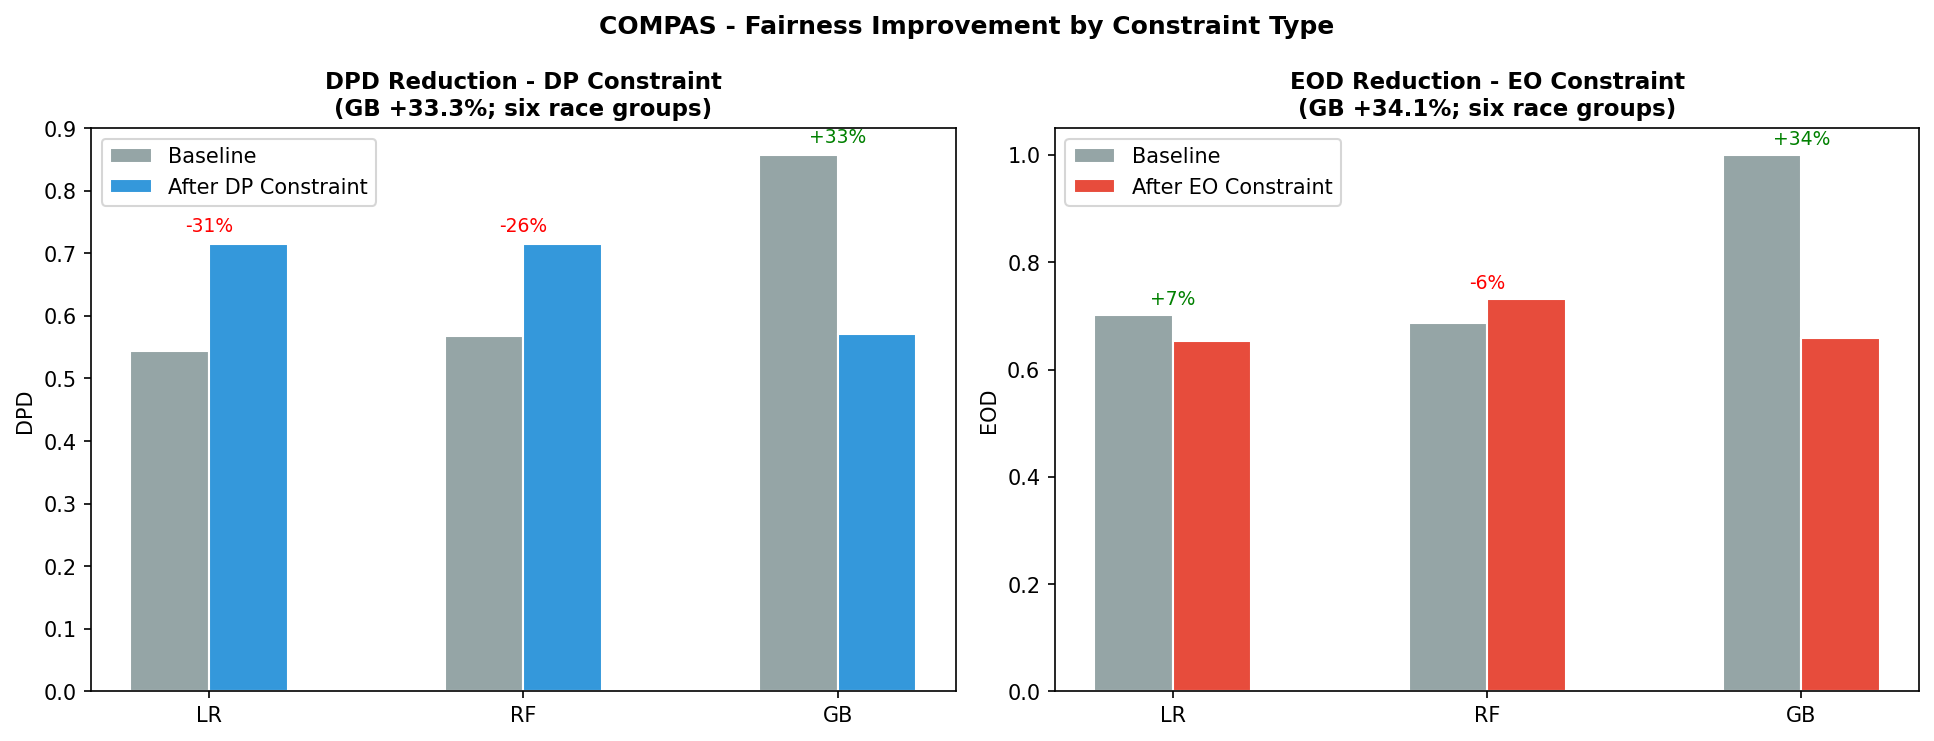

In [4]:
display(Image('figures/stage2/compas_fairness_improvement.png'))

## 3. Accuracy cost against fairness gain

Each model's accuracy cost plotted against its fairness gain under each constraint.

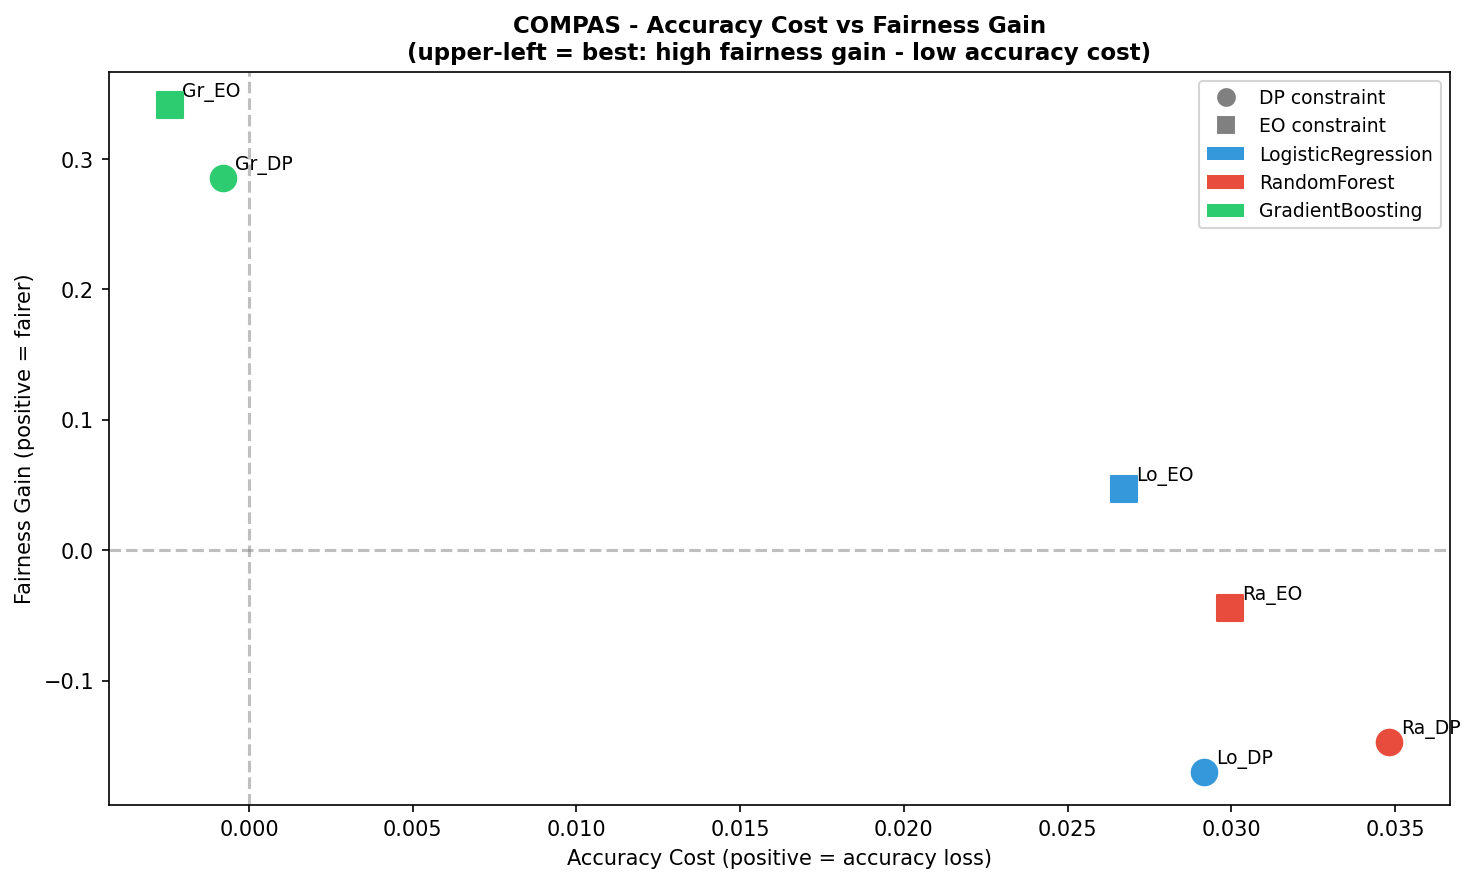

In [5]:
display(Image('figures/stage2/compas_cost_gain_scatter.png'))

## 4. Sex fairness under a constraint on sex

Sex DPD and EOD for each model after the demographic parity constraint is applied on sex.

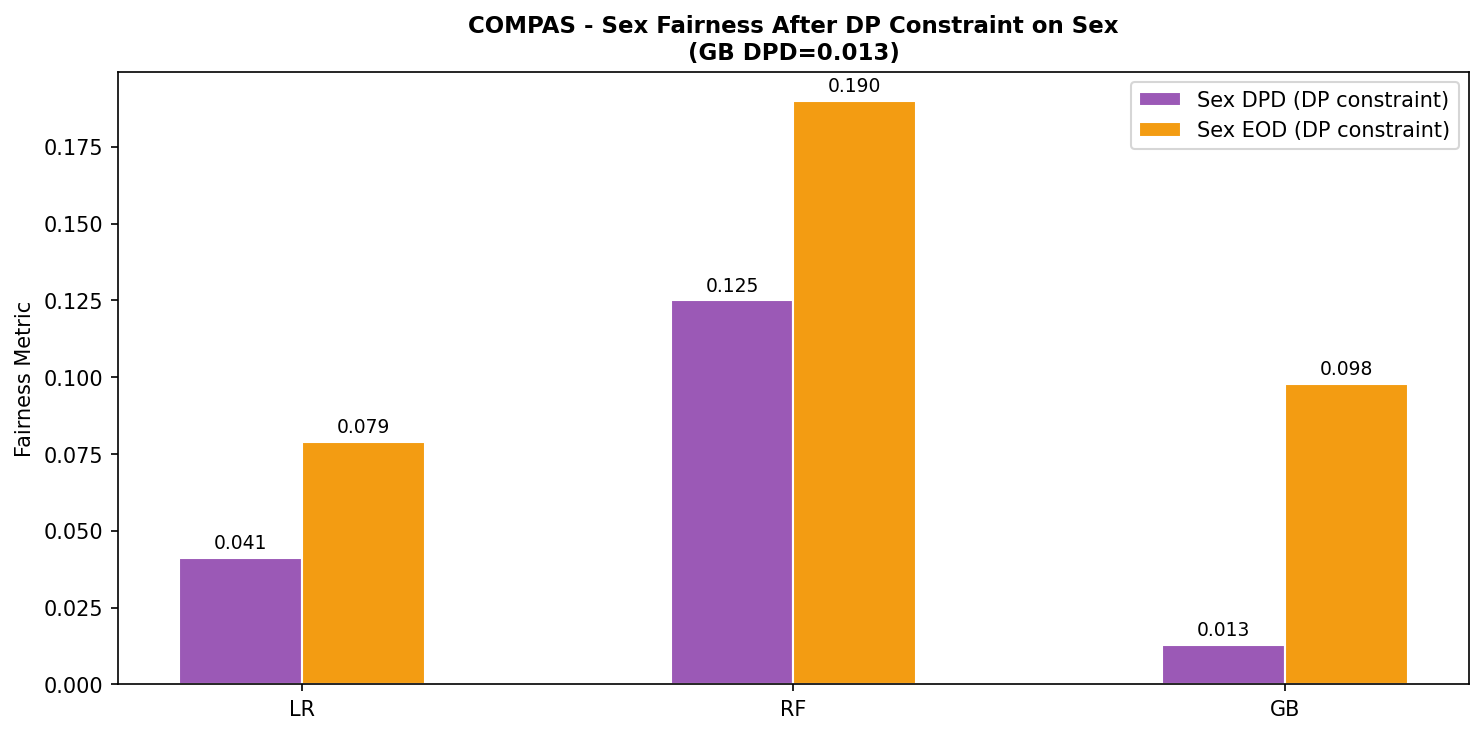

In [6]:
display(Image('figures/stage2/compas_sex_fairness.png'))

## 5. F1 comparison

F1 score for each model at baseline and under each constraint.

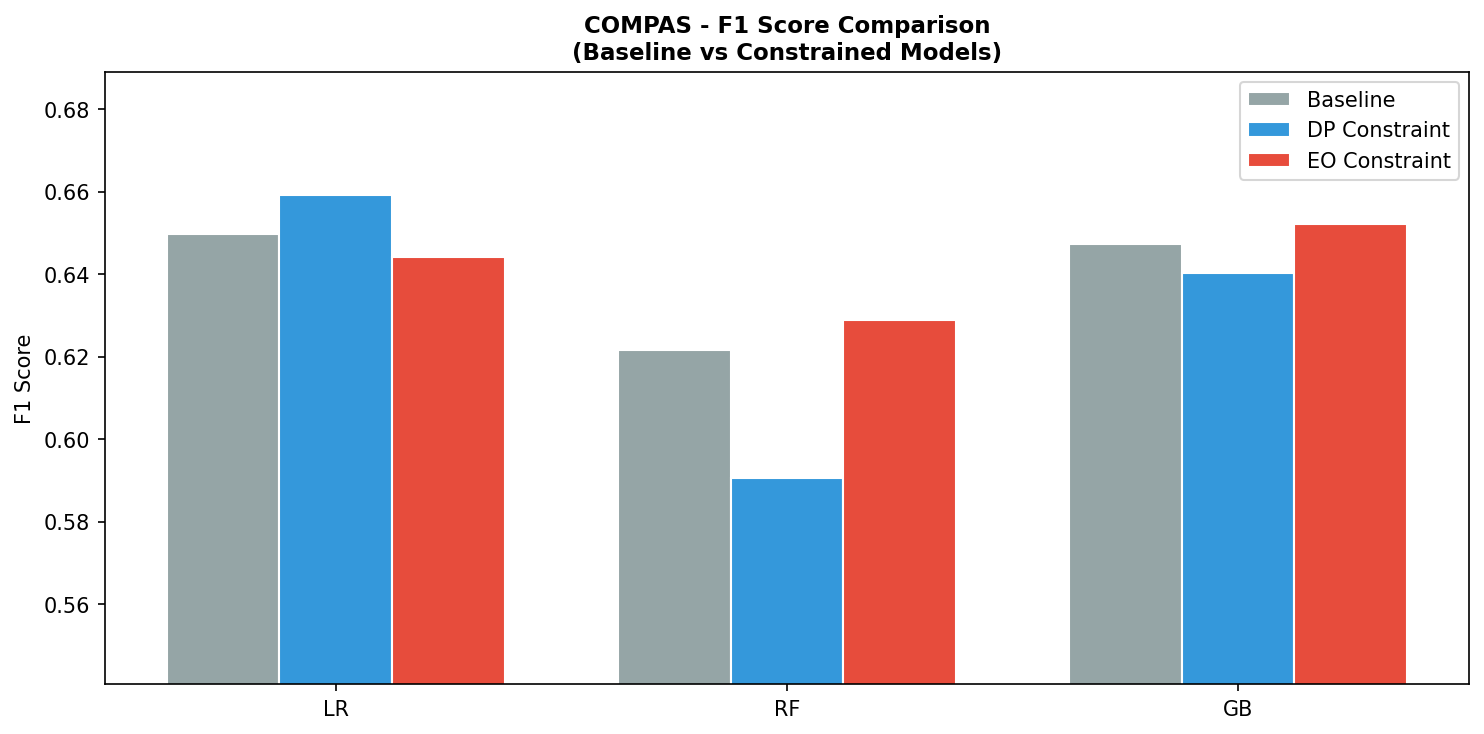

In [7]:
display(Image('figures/stage2/compas_f1_comparison.png'))

## 6. Predicted rates by race

True recidivism rate and gradient boosting's predicted rate by race, at baseline and under the equalized odds constraint.

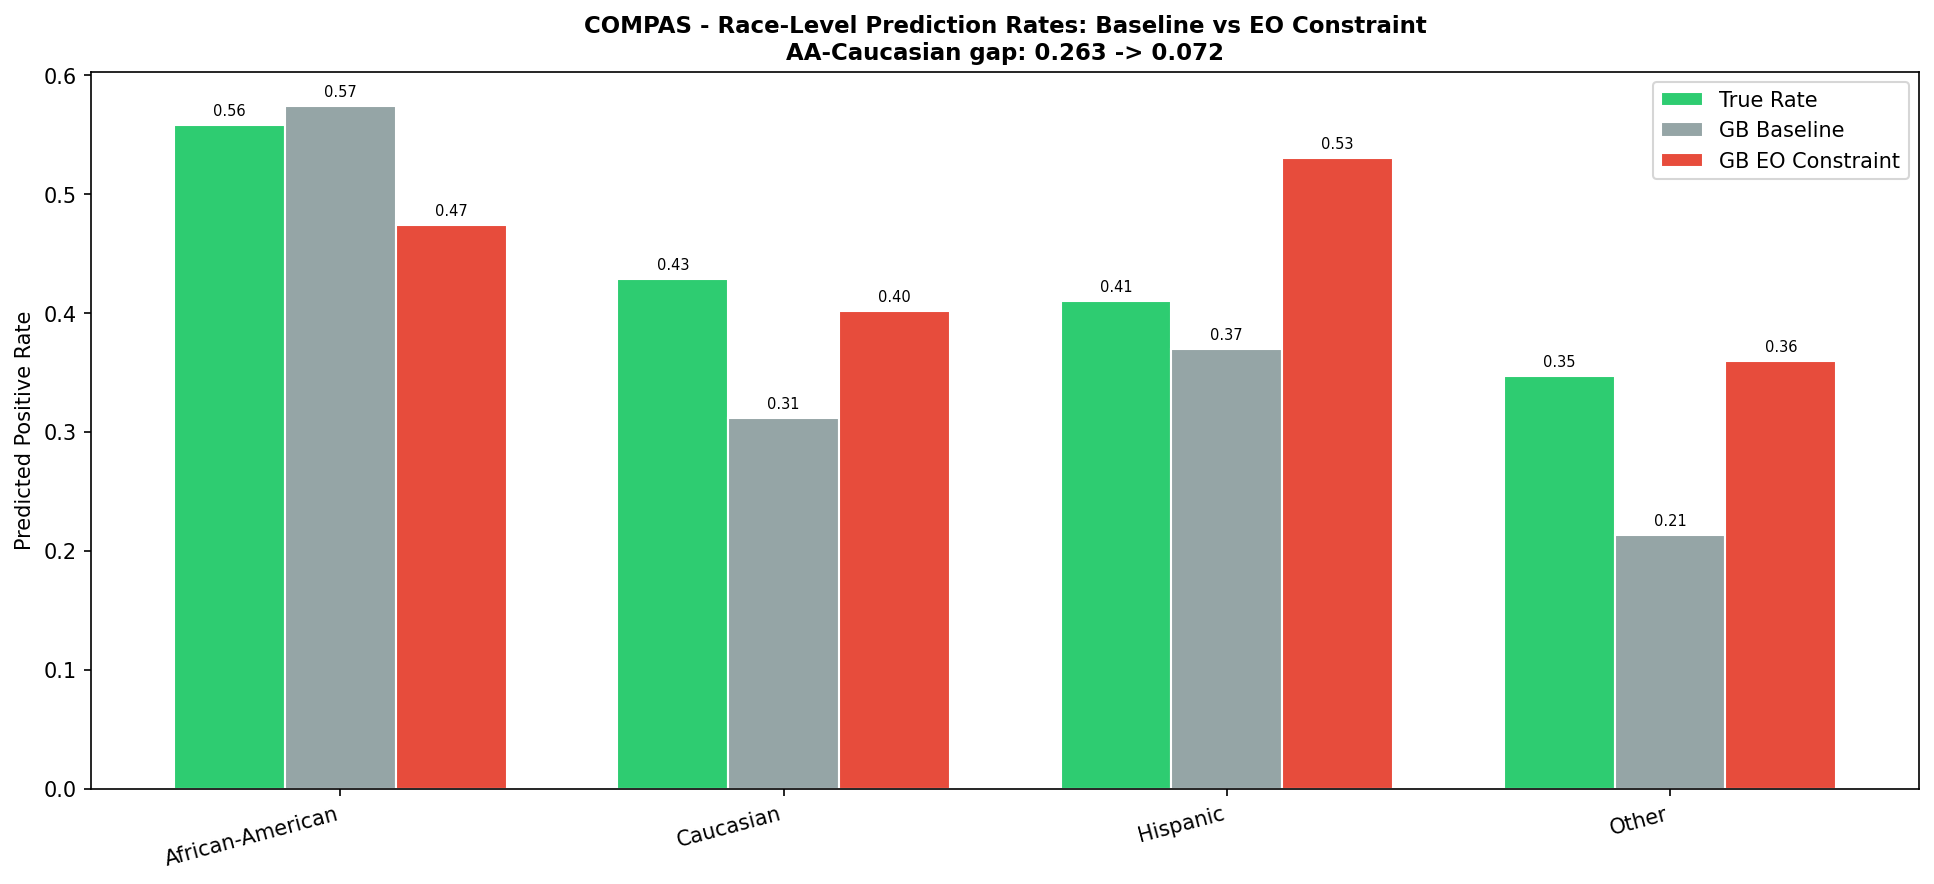

In [8]:
display(Image('figures/stage2/compas_race_prediction_rates.png'))

## 7. FPR and FNR by race

Gradient boosting's false positive and false negative rates by race, at baseline and under the equalized odds constraint.

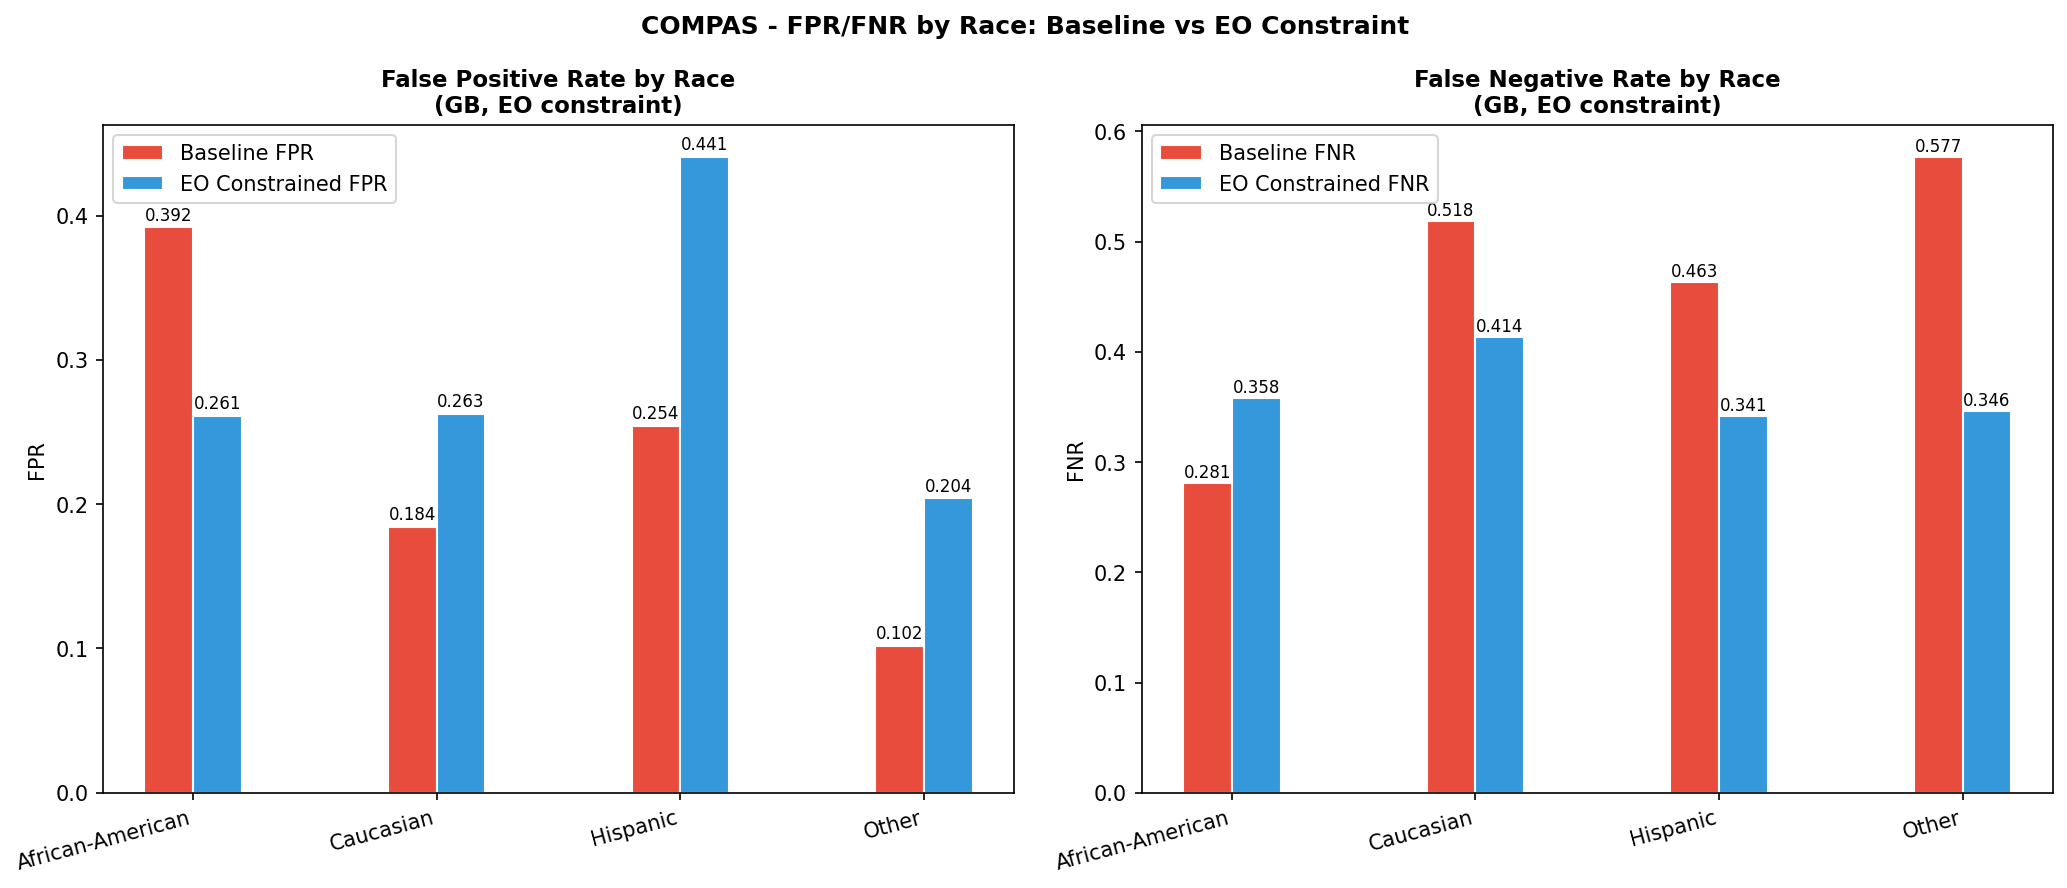

In [9]:
display(Image('figures/stage2/compas_fpr_fnr_by_race.png'))

## 8. Selection-rate ratio before and after the demographic parity constraint

Fairlearn's demographic parity ratio across the race groups for each model, before and after the demographic parity constraint.

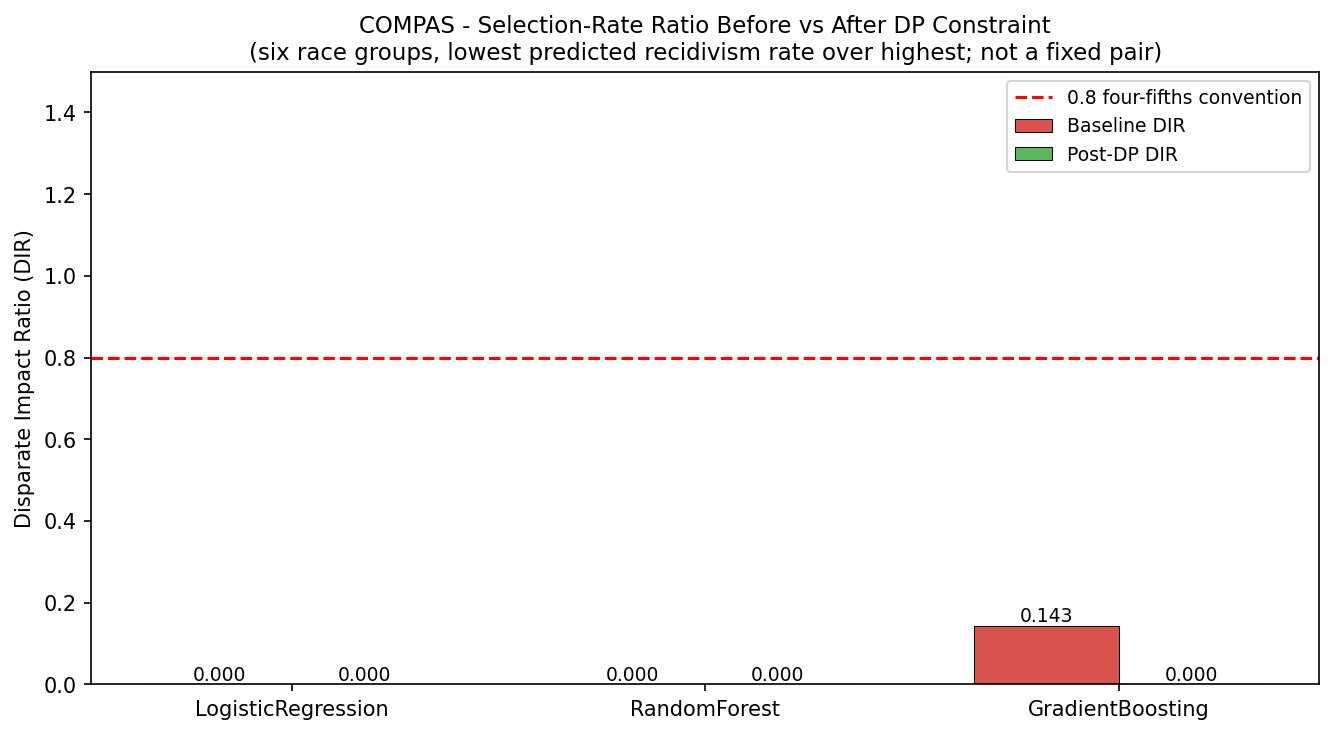

In [10]:
display(Image('figures/stage2/compas_dir_before_after.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.